# Statistical Baseline for EuroSAT RGB

This notebook establishes interpretable statistical benchmarks using
the handcrafted colour and texture features generated during the data
audit.

Models:

1. Most-frequent-class dummy classifier
2. Standardized multinomial logistic regression

The saved 70/15/15 split is reused without modification. Model
selection uses the validation set; the test set remains untouched until
the final configuration is selected.

In [1]:
from pathlib import Path
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path(
    r"C:\Users\comviva\Documents\Eurosat_calibrated"
)

REPORTS_DIR = PROJECT_ROOT / "reports"
SPLITS_DIR = PROJECT_ROOT / "data" / "splits"
RESULTS_DIR = PROJECT_ROOT / "results" / "statistical_baseline"
FIGURES_DIR = RESULTS_DIR / "figures"
MODELS_DIR = PROJECT_ROOT / "models"

for directory in [RESULTS_DIR, FIGURES_DIR, MODELS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

In [2]:
FEATURES_PATH = REPORTS_DIR / "image_statistics.csv"
AUDIT_PATH = REPORTS_DIR / "data_audit.json"

features = pd.read_csv(FEATURES_PATH)

with AUDIT_PATH.open("r") as file:
    audit = json.load(file)

class_names = audit["dataset"]["classes"]
class_indices = list(range(len(class_names)))

print("Feature rows:", len(features))
print("Classes:", class_names)

features.head()

Feature rows: 27000
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


,index,class_index,class_name,mean_red,mean_green,mean_blue,std_red,std_green,std_blue,brightness,contrast,entropy
0,0,0,AnnualCrop,0.427878,0.382109,0.411190,0.060871,0.036548,0.027256,0.399103,0.042042,4.879012
1,1,0,AnnualCrop,0.393011,0.418318,0.373069,0.230804,0.083214,0.067411,0.405486,0.123412,5.455448
2,2,0,AnnualCrop,0.700210,0.588242,0.562894,0.147216,0.070281,0.066756,0.618760,0.092057,5.560011
3,3,0,AnnualCrop,0.601477,0.559049,0.526874,0.232093,0.116114,0.100767,0.567908,0.148350,6.522535
4,4,0,AnnualCrop,0.459737,0.454140,0.471054,0.160504,0.089461,0.075992,0.457753,0.108854,6.281175


In [3]:
def load_partition(split_name: str) -> pd.DataFrame:
    manifest = pd.read_csv(
        SPLITS_DIR / f"{split_name}.csv"
    )

    partition = manifest.merge(
        features,
        left_on="dataset_index",
        right_on="index",
        how="left",
        suffixes=("_manifest", "_features"),
        validate="one_to_one",
    )

    assert len(partition) == len(manifest)
    assert partition["index"].notna().all()

    assert (
        partition["class_index_manifest"]
        == partition["class_index_features"]
    ).all()

    assert (
        partition["class_name_manifest"]
        == partition["class_name_features"]
    ).all()

    return partition


train_data = load_partition("train")
validation_data = load_partition("validation")
test_data = load_partition("test")

print("Training:", len(train_data))
print("Validation:", len(validation_data))
print("Test:", len(test_data))

Training: 18900
Validation: 4050
Test: 4050


In [4]:
train_ids = set(train_data["dataset_index"])
validation_ids = set(validation_data["dataset_index"])
test_ids = set(test_data["dataset_index"])

assert train_ids.isdisjoint(validation_ids)
assert train_ids.isdisjoint(test_ids)
assert validation_ids.isdisjoint(test_ids)

assert len(train_ids | validation_ids | test_ids) == 27_000

print("Split integrity checks passed.")

Split integrity checks passed.


In [5]:
feature_columns = [
    "mean_red",
    "mean_green",
    "mean_blue",
    "std_red",
    "std_green",
    "std_blue",
    "brightness",
    "contrast",
    "entropy",
]

X_train = train_data[feature_columns]
y_train = train_data["class_index_manifest"].astype(int)

X_validation = validation_data[feature_columns]
y_validation = validation_data[
    "class_index_manifest"
].astype(int)

X_test = test_data[feature_columns]
y_test = test_data["class_index_manifest"].astype(int)

assert X_train.isna().sum().sum() == 0
assert X_validation.isna().sum().sum() == 0
assert X_test.isna().sum().sum() == 0

print("Predictors:", feature_columns)
print("Training matrix:", X_train.shape)

Predictors: ['mean_red', 'mean_green', 'mean_blue', 'std_red', 'std_green', 'std_blue', 'brightness', 'contrast', 'entropy']
Training matrix: (18900, 9)


# Minimum Benchmark that the Model must outperform 

In [6]:
def multiclass_brier_score(
    y_true,
    probabilities,
    labels,
):
    """Return the mean summed squared error of multiclass probabilities."""
    label_to_position = {
        label: position
        for position, label in enumerate(labels)
    }

    encoded = np.zeros_like(probabilities)

    for row, label in enumerate(y_true):
        encoded[
            row,
            label_to_position[int(label)]
        ] = 1

    return float(
        np.mean(
            np.sum(
                (probabilities - encoded) ** 2,
                axis=1,
            )
        )
    )


def expected_calibration_error(
    y_true,
    probabilities,
    labels,
    number_of_bins=15,
):
    """Calculate top-label ECE using equal-width confidence bins."""

    labels = np.asarray(labels)
    y_true = np.asarray(y_true)

    predicted_positions = probabilities.argmax(axis=1)
    predicted_labels = labels[predicted_positions]
    confidence = probabilities.max(axis=1)
    correct = predicted_labels == y_true

    bin_edges = np.linspace(0, 1, number_of_bins + 1)
    ece = 0.0

    for bin_index in range(number_of_bins):
        lower = bin_edges[bin_index]
        upper = bin_edges[bin_index + 1]

        if bin_index == number_of_bins - 1:
            mask = (
                (confidence >= lower)
                & (confidence <= upper)
            )
        else:
            mask = (
                (confidence >= lower)
                & (confidence < upper)
            )

        if not mask.any():
            continue

        bin_accuracy = correct[mask].mean()
        bin_confidence = confidence[mask].mean()
        bin_weight = mask.mean()

        ece += (
            bin_weight
            * abs(bin_accuracy - bin_confidence)
        )

    return float(ece)


def evaluate_classifier(
    model,
    X,
    y,
):
    """Return aggregate metrics, predictions and class probabilities."""

    predictions = model.predict(X)
    probabilities = model.predict_proba(X)

    metrics = {
        "accuracy": float(
            accuracy_score(y, predictions)
        ),
        "macro_f1": float(
            f1_score(
                y,
                predictions,
                average="macro",
            )
        ),
        "log_loss": float(
            log_loss(
                y,
                probabilities,
                labels=class_indices,
            )
        ),
        "multiclass_brier_score": (
            multiclass_brier_score(
                y,
                probabilities,
                class_indices,
            )
        ),
        "expected_calibration_error": (
            expected_calibration_error(
                y,
                probabilities,
                class_indices,
            )
        ),
    }

    return metrics, predictions, probabilities

In [7]:
dummy_model = DummyClassifier(
    strategy="most_frequent"
)

dummy_model.fit(X_train, y_train)

(
    dummy_validation_metrics,
    dummy_validation_predictions,
    dummy_validation_probabilities,
) = evaluate_classifier(
    dummy_model,
    X_validation,
    y_validation,
)

pd.Series(
    dummy_validation_metrics,
    name="dummy_validation",
)

accuracy                       0.111111
macro_f1                       0.020000
log_loss                      32.038803
multiclass_brier_score         1.777778
expected_calibration_error     0.888889
Name: dummy_validation, dtype: float64

In [8]:
prior_dummy_model = DummyClassifier(
    strategy="prior"
)

prior_dummy_model.fit(X_train, y_train)

(
    prior_dummy_metrics,
    prior_dummy_predictions,
    prior_dummy_probabilities,
) = evaluate_classifier(
    prior_dummy_model,
    X_validation,
    y_validation,
)

pd.Series(
    prior_dummy_metrics,
    name="prior_probability_baseline",
)

accuracy                      1.111111e-01
macro_f1                      2.000000e-02
log_loss                      2.294786e+00
multiclass_brier_score        8.984911e-01
expected_calibration_error    2.775558e-17
Name: prior_probability_baseline, dtype: float64

# Training Multinomial Logistic Regression Model

In [9]:
regularization_candidates = [
    0.001,
    0.01,
    0.1,
    1.0,
    10.0,
    100.0,
]

validation_results = []
candidate_models = {}

for C in regularization_candidates:
    pipeline = Pipeline([
        (
            "scaler",
            StandardScaler(),
        ),
        (
            "classifier",
            LogisticRegression(
                C=C,
                solver="lbfgs",
                max_iter=3000,
            ),
        ),
    ])

    pipeline.fit(X_train, y_train)

    metrics, predictions, probabilities = (
        evaluate_classifier(
            pipeline,
            X_validation,
            y_validation,
        )
    )

    validation_results.append({
        "C": C,
        **metrics,
    })

    candidate_models[C] = pipeline

validation_results = pd.DataFrame(
    validation_results
).sort_values(
    by=["macro_f1", "log_loss"],
    ascending=[False, True],
)

validation_results

,C,accuracy,macro_f1,log_loss,multiclass_brier_score,expected_calibration_error
5,100.000,0.740000,0.726702,0.754712,0.366125,0.016764
4,10.000,0.732099,0.718900,0.771279,0.374029,0.018252
3,1.000,0.724198,0.709846,0.801079,0.386599,0.034079
2,0.100,0.709136,0.691701,0.869271,0.414447,0.090672
1,0.010,0.674815,0.652512,1.096036,0.508757,0.197798
0,0.001,0.541975,0.470698,1.477202,0.659105,0.227854


In [10]:
best_C = float(validation_results.iloc[0]["C"])
best_validation_model = candidate_models[best_C]

print("Selected C:", best_C)
display(validation_results)

Selected C: 100.0


,C,accuracy,macro_f1,log_loss,multiclass_brier_score,expected_calibration_error
5,100.000,0.740000,0.726702,0.754712,0.366125,0.016764
4,10.000,0.732099,0.718900,0.771279,0.374029,0.018252
3,1.000,0.724198,0.709846,0.801079,0.386599,0.034079
2,0.100,0.709136,0.691701,0.869271,0.414447,0.090672
1,0.010,0.674815,0.652512,1.096036,0.508757,0.197798
0,0.001,0.541975,0.470698,1.477202,0.659105,0.227854


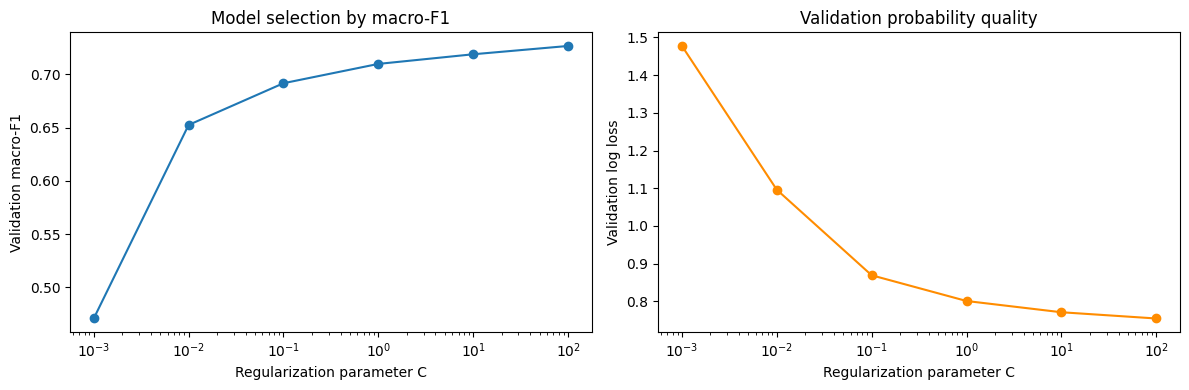

In [11]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12, 4),
)

axes[0].plot(
    validation_results["C"],
    validation_results["macro_f1"], # Higher is better 
    marker="o",
)
axes[0].set_xscale("log")
axes[0].set_xlabel("Regularization parameter C")
axes[0].set_ylabel("Validation macro-F1")
axes[0].set_title("Model selection by macro-F1")

axes[1].plot(
    validation_results["C"],
    validation_results["log_loss"], # Lower is better 
    marker="o",
    color="darkorange",
)
axes[1].set_xscale("log")
axes[1].set_xlabel("Regularization parameter C")
axes[1].set_ylabel("Validation log loss")
axes[1].set_title("Validation probability quality")

fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "regularization_selection.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

The selected regularization parameter, C=100, was the upper boundary of
the predefined search grid. Therefore, this experiment does not
establish that the optimal regularization strength was fully bracketed.
The configuration is retained as the frozen statistical baseline rather
than being adjusted after observing test performance.

In [12]:
# Comparison between the baseline and selected logistic-regression model
(
    logistic_validation_metrics,
    logistic_validation_predictions,
    logistic_validation_probabilities,
) = evaluate_classifier(
    best_validation_model,
    X_validation,
    y_validation,
)

validation_comparison = pd.DataFrame([
    {
        "model": "Most-frequent dummy",
        **dummy_validation_metrics,
    },
    {
        "model": "Class-prior dummy",
        **prior_dummy_metrics,
    },
    {
        "model": "Multinomial logistic regression",
        **logistic_validation_metrics,
    },
])

validation_comparison

,model,accuracy,macro_f1,log_loss,multiclass_brier_score,expected_calibration_error
0,Most-frequent dummy,0.111111,0.020000,32.038803,1.777778,8.888889e-01
1,Class-prior dummy,0.111111,0.020000,2.294786,0.898491,2.775558e-17
2,Multinomial logistic regression,0.740000,0.726702,0.754712,0.366125,1.676394e-02


In [13]:
validation_report = classification_report(
    y_validation,
    logistic_validation_predictions,
    labels=class_indices,
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)

validation_report_df = (
    pd.DataFrame(validation_report)
    .transpose()
)

validation_report_df

,precision,recall,f1-score,support
AnnualCrop,0.767981,0.735556,0.751419,450.00
Forest,0.839323,0.882222,0.860238,450.00
HerbaceousVegetation,0.712500,0.760000,0.735484,450.00
Highway,0.452962,0.346667,0.392749,375.00
Industrial,0.873016,0.880000,0.876494,375.00
Pasture,0.647416,0.710000,0.677266,300.00
PermanentCrop,0.608696,0.597333,0.602961,375.00
Residential,0.771372,0.862222,0.814271,450.00
River,0.665746,0.642667,0.654003,375.00
SeaLake,0.913440,0.891111,0.902137,450.00


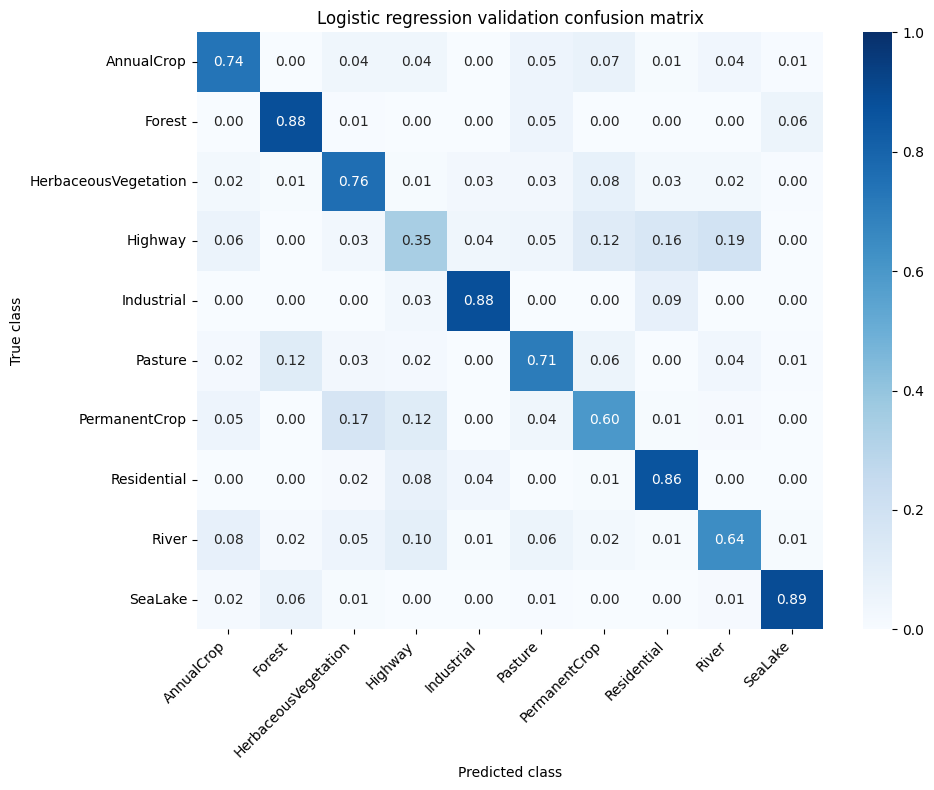

In [14]:
validation_confusion = confusion_matrix(
    y_validation,
    logistic_validation_predictions,
    labels=class_indices,
    normalize="true",
)

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    validation_confusion,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    vmin=0,
    vmax=1,
    ax=ax,
)

ax.set_title(
    "Logistic regression validation confusion matrix"
)
ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

fig.tight_layout()
fig.savefig(
    FIGURES_DIR
    / "validation_confusion_matrix.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

## Validation-set error analysis

The multinomial logistic-regression model achieved a validation
macro-F1 of 0.727, substantially outperforming the most-frequent-class
baseline.

The confusion matrix does not measure correlation between classes.
Instead, it shows which land-cover classes are difficult to separate
using the available colour and texture features.

The weakest validation class was Highway, with an F1-score of 0.393.
PermanentCrop and River were also comparatively difficult. These
results suggest that global RGB, brightness, contrast and entropy
summaries do not fully capture spatial structures such as road shape,
field boundaries, building arrangement and water geometry.

This supports the next project stage: comparing these statistical
features with spatial representations learned by a CNN. 

In [15]:
X_train_validation = pd.concat(
    [X_train, X_validation],
    axis=0,
)

y_train_validation = pd.concat(
    [y_train, y_validation],
    axis=0,
)

final_logistic_model = Pipeline([
    (
        "scaler",
        StandardScaler(),
    ),
    (
        "classifier",
        LogisticRegression(
            C=best_C,
            solver="lbfgs",
            max_iter=3000,
        ),
    ),
])

final_logistic_model.fit(
    X_train_validation,
    y_train_validation,
)

print("Final model fitted with C =", best_C)

Final model fitted with C = 100.0


In [16]:
(
    test_metrics,
    test_predictions,
    test_probabilities,
) = evaluate_classifier(
    final_logistic_model,
    X_test,
    y_test,
)

pd.Series(
    test_metrics,
    name="logistic_regression_test",
)

accuracy                      0.747654
macro_f1                      0.734614
log_loss                      0.737415
multiclass_brier_score        0.360327
expected_calibration_error    0.024566
Name: logistic_regression_test, dtype: float64

In [17]:
test_report = classification_report(
    y_test,
    test_predictions,
    labels=class_indices,
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)

test_report_df = (
    pd.DataFrame(test_report)
    .transpose()
)

test_report_df

,precision,recall,f1-score,support
AnnualCrop,0.817734,0.737778,0.775701,450.000000
Forest,0.853249,0.904444,0.878101,450.000000
HerbaceousVegetation,0.717842,0.768889,0.742489,450.000000
Highway,0.434028,0.333333,0.377074,375.000000
Industrial,0.868895,0.901333,0.884817,375.000000
Pasture,0.664820,0.800000,0.726172,300.000000
PermanentCrop,0.640805,0.594667,0.616874,375.000000
Residential,0.743738,0.857778,0.796698,450.000000
River,0.662890,0.624000,0.642857,375.000000
SeaLake,0.929742,0.882222,0.905359,450.000000


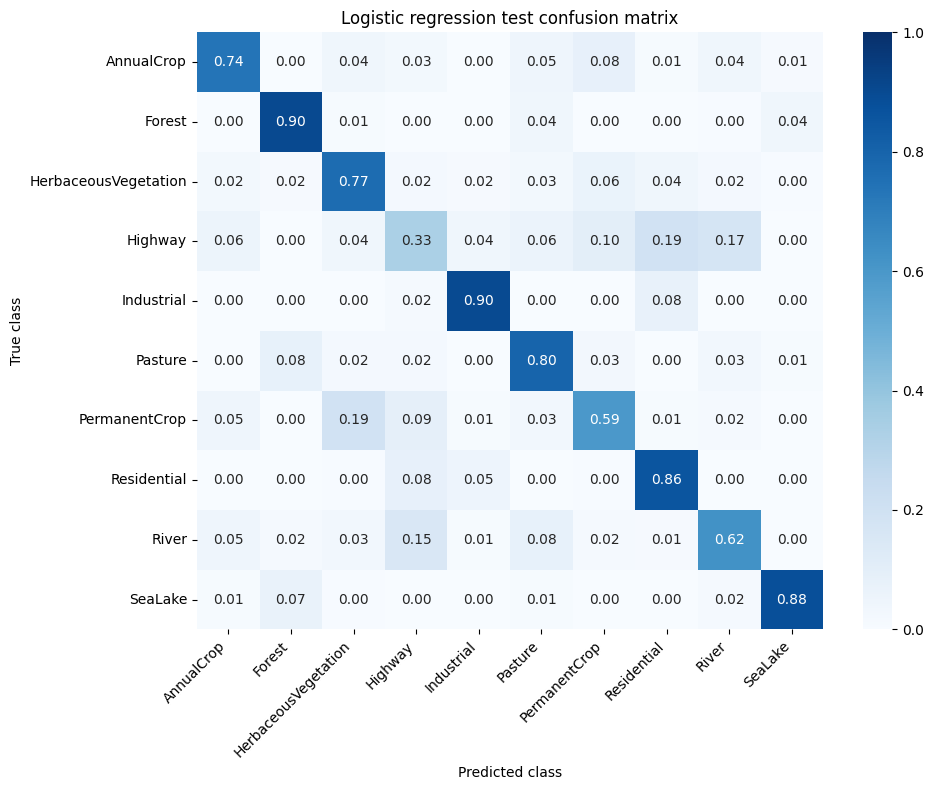

In [18]:
test_confusion = confusion_matrix(
    y_test,
    test_predictions,
    labels=class_indices,
    normalize="true",
)

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    test_confusion,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    vmin=0,
    vmax=1,
    ax=ax,
)

ax.set_title(
    "Logistic regression test confusion matrix"
)
ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "test_confusion_matrix.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

In [19]:
classifier = final_logistic_model.named_steps[
    "classifier"
]

coefficient_table = pd.DataFrame(
    classifier.coef_,
    index=class_names,
    columns=feature_columns,
)

coefficient_table

,mean_red,mean_green,mean_blue,std_red,std_green,std_blue,brightness,contrast,entropy
AnnualCrop,1.043461,2.807317,-2.411031,11.563610,11.606994,-4.076529,1.724400,-15.748580,-5.673794
Forest,-4.863961,2.359464,-3.855637,4.694369,2.842394,-11.424081,1.557849,-9.295791,-1.078970
HerbaceousVegetation,5.932856,-1.996652,-0.575788,-42.991086,-51.932084,-9.807919,-2.174662,103.005041,0.965044
Highway,1.055625,-4.115836,0.273675,9.913684,12.304125,5.918779,2.484681,-23.706467,-0.382493
Industrial,1.076307,-6.476098,6.743916,0.238024,-0.849422,15.525732,-1.932202,-10.919768,6.240340
Pasture,-6.711418,7.964658,-1.520473,8.918740,3.690614,-4.165885,-0.889160,-12.393633,0.774461
PermanentCrop,1.183141,1.806913,-3.234575,-0.196896,3.161566,-3.613095,1.659653,0.882407,2.131741
Residential,5.620245,-7.339129,3.851824,-4.572276,-8.101808,15.855704,-1.879706,-6.308040,10.293404
River,-1.949491,0.744741,0.727203,11.280802,21.090050,0.377229,-0.976492,-27.202701,-2.562035
SeaLake,-2.386765,4.244622,0.000886,1.151028,6.187573,-4.589935,0.425639,1.687532,-10.707698


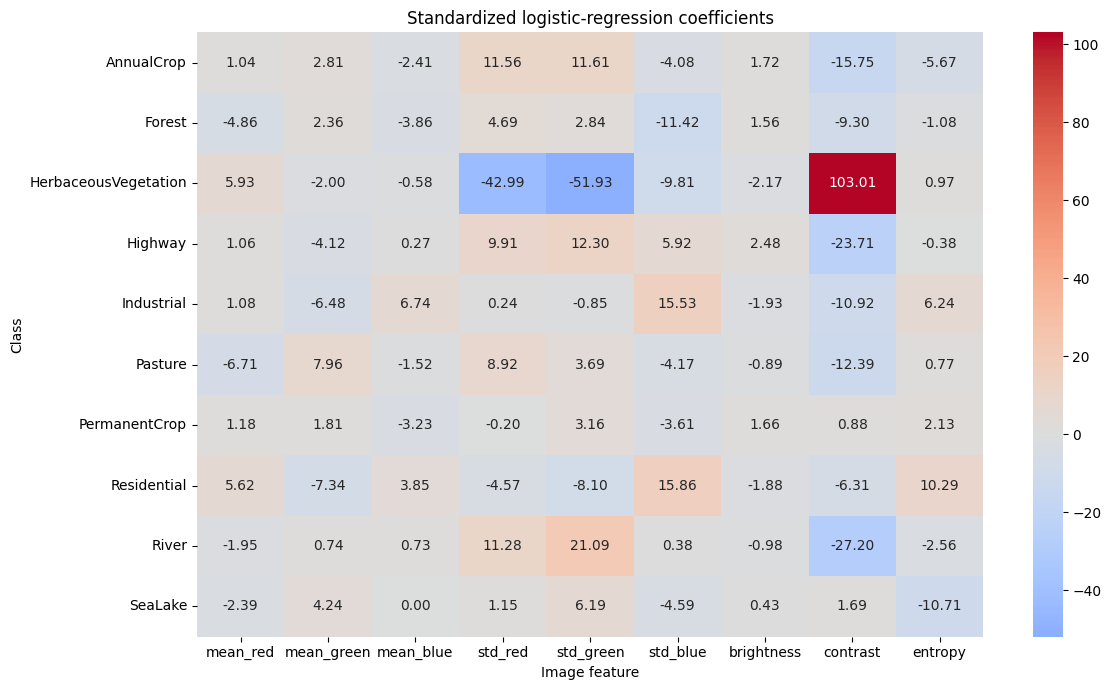

In [20]:
fig, ax = plt.subplots(figsize=(12, 7))

sns.heatmap(
    coefficient_table,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    ax=ax,
)

ax.set_title(
    "Standardized logistic-regression coefficients"
)
ax.set_xlabel("Image feature")
ax.set_ylabel("Class")

fig.tight_layout()
fig.savefig(
    FIGURES_DIR
    / "logistic_coefficients.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

In [21]:
validation_results.to_csv(
    RESULTS_DIR / "regularization_search.csv",
    index=False,
)

validation_comparison.to_csv(
    RESULTS_DIR / "validation_model_comparison.csv",
    index=False,
)

validation_report_df.to_csv(
    RESULTS_DIR / "validation_classification_report.csv"
)

test_report_df.to_csv(
    RESULTS_DIR / "test_classification_report.csv"
)

coefficient_table.to_csv(
    RESULTS_DIR / "logistic_coefficients.csv"
)

In [22]:
test_prediction_table = test_data[
    [
        "dataset_index",
        "relative_path",
        "class_name_manifest",
        "class_index_manifest",
    ]
].copy()

test_prediction_table = (
    test_prediction_table.reset_index(drop=True)
)

test_prediction_table["predicted_class_index"] = (
    test_predictions
)

test_prediction_table["predicted_class_name"] = [
    class_names[index]
    for index in test_predictions
]

test_prediction_table["confidence"] = (
    test_probabilities.max(axis=1)
)

test_prediction_table["correct"] = (
    test_prediction_table["class_index_manifest"]
    == test_prediction_table["predicted_class_index"]
)

for class_index, class_name in enumerate(class_names):
    test_prediction_table[
        f"probability_{class_name}"
    ] = test_probabilities[:, class_index]

test_prediction_table.to_csv(
    RESULTS_DIR / "test_predictions.csv",
    index=False,
)

In [23]:
joblib.dump(
    final_logistic_model,
    MODELS_DIR / "statistical_logistic_regression.joblib",
)

experiment_summary = {
    "model": "multinomial logistic regression",
    "features": feature_columns,
    "selected_C": best_C,
    "selection_metric": "validation macro-F1",
    "split_seed": audit["split"]["seed"],
    "training_samples": len(X_train),
    "validation_samples": len(X_validation),
    "final_fit_samples": len(X_train_validation),
    "test_samples": len(X_test),
    "validation_metrics": logistic_validation_metrics,
    "test_metrics": test_metrics,
    "limitations": [
        "Image-level split does not measure geographic generalization.",
        "Handcrafted features are predictive summaries rather than causal variables.",
        "Test results must not be used for further hyperparameter selection.",
    ],
}

with (
    RESULTS_DIR / "experiment_summary.json"
).open("w") as file:
    json.dump(
        experiment_summary,
        file,
        indent=2,
    )

## Final evaluation

The frozen multinomial logistic-regression pipeline achieved:

- Test accuracy: 0.748
- Test macro-F1: 0.735
- Test log loss: 0.737
- Multiclass Brier score: 0.360
- Top-label expected calibration error: 0.025

Validation and test performance were similar, with macro-F1 values of
0.727 and 0.735 respectively. This provides no evidence of a large
generalization gap under the fixed image-level split, although it does
not establish geographic generalization.

The strongest test classes were SeaLake, Industrial and Forest. The
weakest was Highway, followed by PermanentCrop and River.

The most frequent directional errors included:

- PermanentCrop → HerbaceousVegetation: 73 images
- Highway → Residential: 72 images
- Highway → River: 65 images
- River → Highway: 58 images
- AnnualCrop → PermanentCrop: 38 images

These errors broadly agree with the visual ambiguities identified
during EDA. Global colour and texture summaries distinguish several
classes effectively, but they discard spatial information needed to
represent roads, rivers, crop boundaries and building layouts.

The next experiment will test whether frozen ResNet18 embeddings provide
a stronger representation while retaining a simple linear classifier.

### Limitations

- The split is stratified at image level and does not measure
  generalization to unseen geographic regions.
- Exact duplicates were excluded, but geographically related or
  near-duplicate patches may still cross partitions.
- Top-label ECE is an aggregate calibration statistic and may conceal
  class-specific calibration errors.
- Strong predictor correlations make individual logistic-regression
  coefficients unstable.
- C=100 was the upper boundary of the predefined search grid.
- The test set has now been evaluated and must remain locked for this
  statistical baseline.